In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:

df = pd.read_csv('Housing.csv')

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")

Rows: 545
Columns: 13

Column names: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [4]:
target = 'price'
features = [col for col in df.columns if col != target]

print(f"Target variable: {target}")
print(f"Feature columns ({len(features)}): {features}")

Target variable: price
Feature columns (12): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


In [7]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 0
Shape after removing duplicates: (545, 13)


In [8]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df[binary_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [9]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [10]:
print(df.dtypes)
print(f"\nFinal shape: {df.shape}")
print(f"Final columns: {list(df.columns)}")

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

Final shape: (545, 14)
Final columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [11]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 436 rows
Test set: 109 rows


In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance:")
print(f"MAE:  ₹{lr_mae:,.0f}")
print(f"RMSE: ₹{lr_rmse:,.0f}")
print(f"R²:   {lr_r2:.4f}")

Linear Regression Performance:
MAE:  ₹970,043
RMSE: ₹1,324,507
R²:   0.6529


In [13]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Performance:")
print(f"MAE:  ₹{rf_mae:,.0f}")
print(f"RMSE: ₹{rf_rmse:,.0f}")
print(f"R²:   {rf_r2:.4f}")

Random Forest Performance:
MAE:  ₹1,022,560
RMSE: ₹1,401,497
R²:   0.6114


In [14]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R² Score': [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


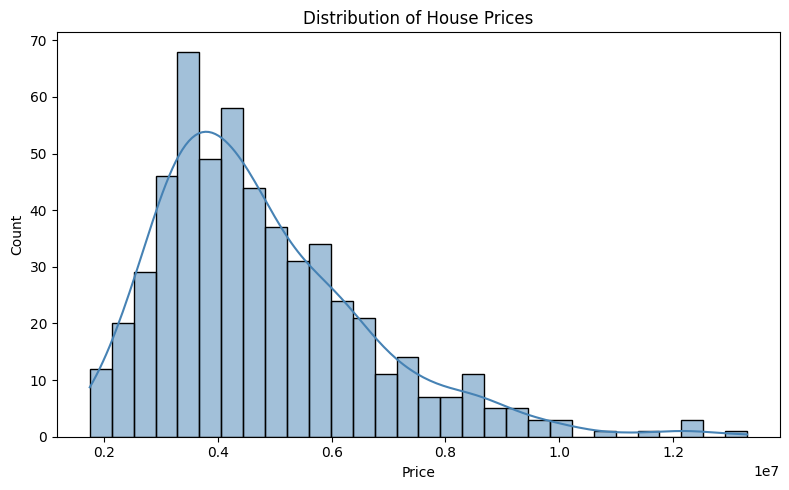

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

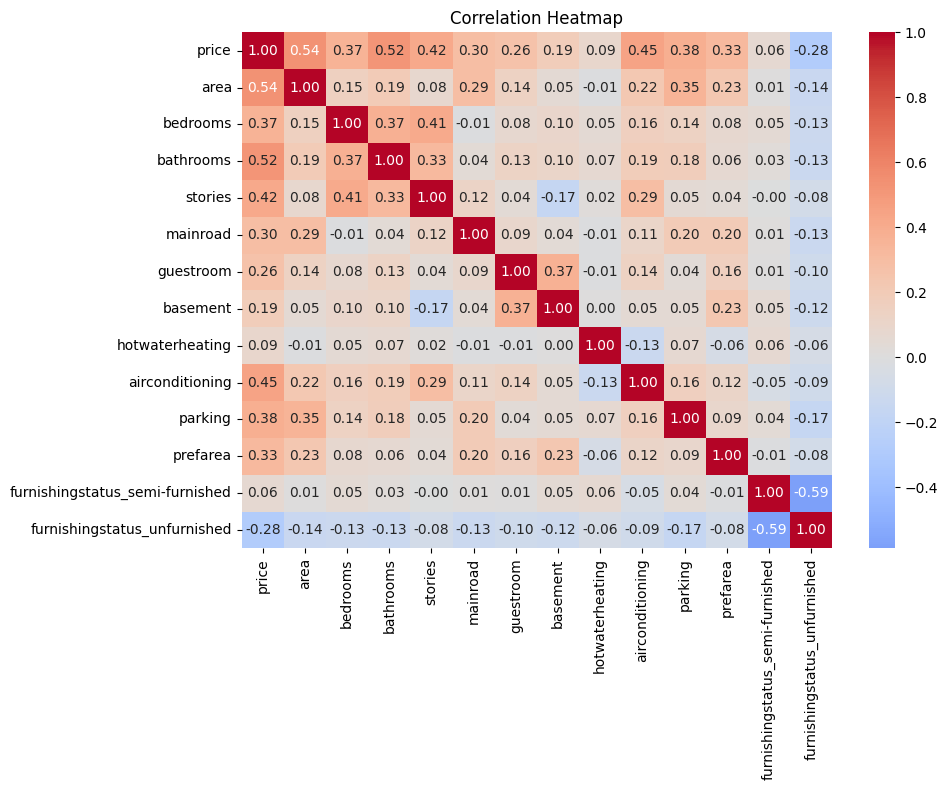

In [17]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

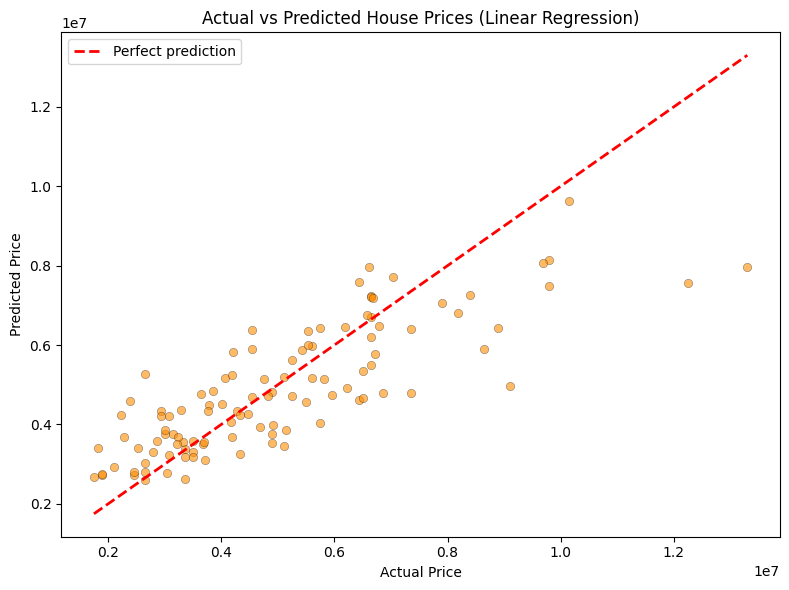

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_preds, alpha=0.6, color='darkorange', edgecolor='k', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices (Linear Regression)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

## Task 5: Insights & Summary

Based on the correlation analysis and Random Forest feature importances, **area, bathrooms, and air conditioning** are the strongest drivers of house price in this dataset, with area alone accounting for nearly half of the Random Forest's predictive importance. Bedrooms, somewhat surprisingly, mattered far less than bathrooms a 4-bedroom house isn't worth dramatically more on its own, but more bathrooms consistently push price up.

In plain terms, the Linear Regression model explains about **65% of the variation in house prices** (R² = 0.65), with a typical prediction error of around ₹9.7 lakh on houses averaging roughly ₹47.7 lakh so predictions are usually in the right ballpark but not pinpoint-accurate. Random Forest performed slightly worse (R² = 0.61), which was the most surprising finding: a more complex model didn't help here, likely because the dataset is small (545 rows) and the relationships are mostly linear, so the simpler model generalized better.

**Recommendation for a real estate business:** marketing and pricing strategy should lean heavily on area, bathroom count, and air conditioning as the headline value features, since these move price the most — while features like hot water heating or furnishing status barely moved the needle and shouldn't be over-emphasized in listings.